In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [15]:
#load the dataset
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [ ]:
#basic inspection
print("Shape:", df.shape)

display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom



Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268


In [ ]:
#understand the dataset
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,"541,909.00","25,900.00","573,585.00","1,114.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"541,909.00",NaN,NaN,NaN,9.55,"-80,995.00",1.00,3.00,10.00,"80,995.00",218.08
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,"541,909.00",NaN,NaN,NaN,4.61,"-11,062.06",1.25,2.08,4.13,"38,970.00",96.76
CustomerID,"406,829.00",NaN,NaN,NaN,"15,287.69","12,346.00","13,953.00","15,152.00","16,791.00","18,287.00","1,713.60"
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#create cancellation flag
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["IsCancelled"] = df["InvoiceNo"].str.startswith("C")

print(df["IsCancelled"].value_counts())

IsCancelled
False    532621
True       9288
Name: count, dtype: int64


In [ ]:
#clean the data
clean_df = df.copy()

clean_df = clean_df.drop_duplicates()

clean_df = clean_df[
    (~clean_df["IsCancelled"]) &
    (clean_df["Quantity"] > 0) &
    (clean_df["UnitPrice"] > 0)
]

clean_df["Revenue"] = clean_df["Quantity"] * clean_df["UnitPrice"]

print("Original rows:", len(df))
print("Clean rows:", len(clean_df))

Original rows: 541909
Clean rows: 524878


In [ ]:
#customer-level dataset
customer_df = clean_df.dropna(subset=["CustomerID"]).copy()

customer_df["CustomerID"] = customer_df["CustomerID"].astype(int)

print("Customer-level rows:", len(customer_df))
print("Unique customers:", customer_df["CustomerID"].nunique())

Customer-level rows: 392692
Unique customers: 4338


In [ ]:
#KPIs
total_revenue = clean_df["Revenue"].sum()
total_orders = clean_df["InvoiceNo"].nunique()
unique_customers = customer_df["CustomerID"].nunique()

avg_order_value = total_revenue / total_orders
revenue_per_customer = total_revenue / unique_customers

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Average Order Value: £{avg_order_value:,.2f}")
print(f"Revenue per Customer: £{revenue_per_customer:,.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Unique Customers: 4,338
Average Order Value: £533.17
Revenue per Customer: £2,453.23


## Customer Purchase Behaviour

We analyze purchasing frequency to understand how many customers return for additional purchases versus making only a single order.

In [16]:
orders_per_customer = (
    customer_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

repeat_customers = (orders_per_customer > 1).sum()
one_time_customers = (orders_per_customer == 1).sum()

repeat_customer_rate = repeat_customers / len(orders_per_customer) * 100

print(f"Repeat Customers: {repeat_customers:,}")
print(f"One-Time Customers: {one_time_customers:,}")
print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

Repeat Customers: 2,845
One-Time Customers: 1,493
Repeat Customer Rate: 65.58%


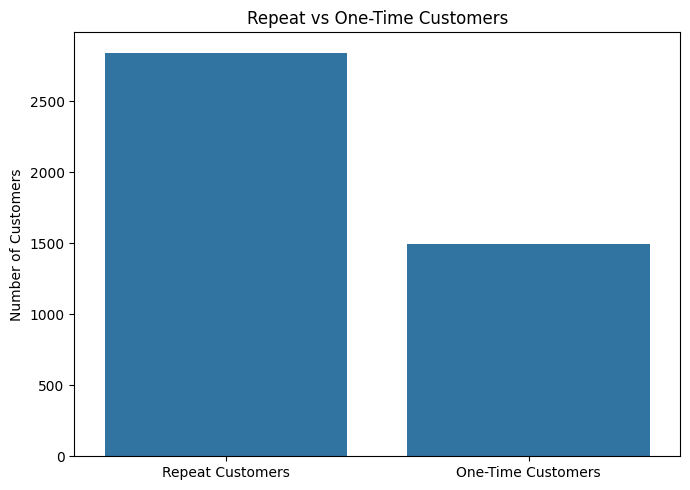

In [17]:
customer_type = pd.DataFrame({
    "Customer Type": ["Repeat Customers", "One-Time Customers"],
    "Customers": [repeat_customers, one_time_customers]
})

plt.figure(figsize=(7, 5))
sns.barplot(
    data=customer_type,
    x="Customer Type",
    y="Customers"
)

plt.title("Repeat vs One-Time Customers")
plt.xlabel("")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Revenue Trend Analysis

Monthly revenue is analyzed to identify growth patterns, demand changes, and possible seasonality.

In [18]:
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    clean_df.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)

monthly_revenue

,Month,Revenue
0,2010-12,"821,452.73"
1,2011-01,"689,811.61"
2,2011-02,"522,545.56"
3,2011-03,"716,215.26"
4,2011-04,"536,968.49"
5,2011-05,"769,296.61"
6,2011-06,"760,547.01"
7,2011-07,"718,076.12"
8,2011-08,"757,841.38"
9,2011-09,"1,056,435.19"


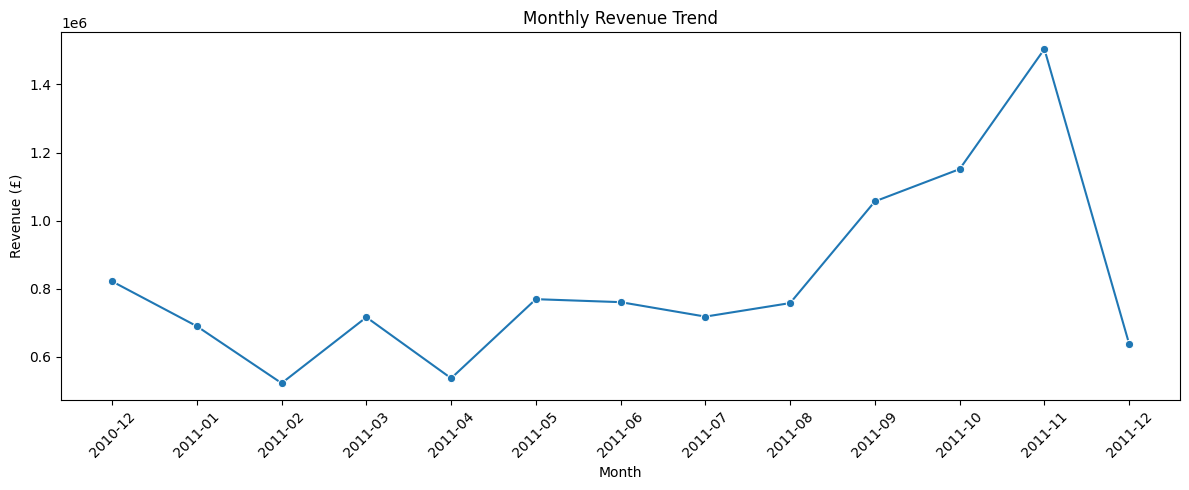

In [19]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Geographic Revenue Analysis

Revenue by country is analyzed to identify the strongest international markets outside the retailer's primary United Kingdom market.

In [20]:
country_revenue = (
    clean_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom   9,001,744.09
Netherlands        285,446.34
EIRE               283,140.52
Germany            228,678.40
France             209,625.37
Australia          138,453.81
Spain               61,558.56
Switzerland         57,067.60
Belgium             41,196.34
Sweden              38,367.83
Name: Revenue, dtype: float64

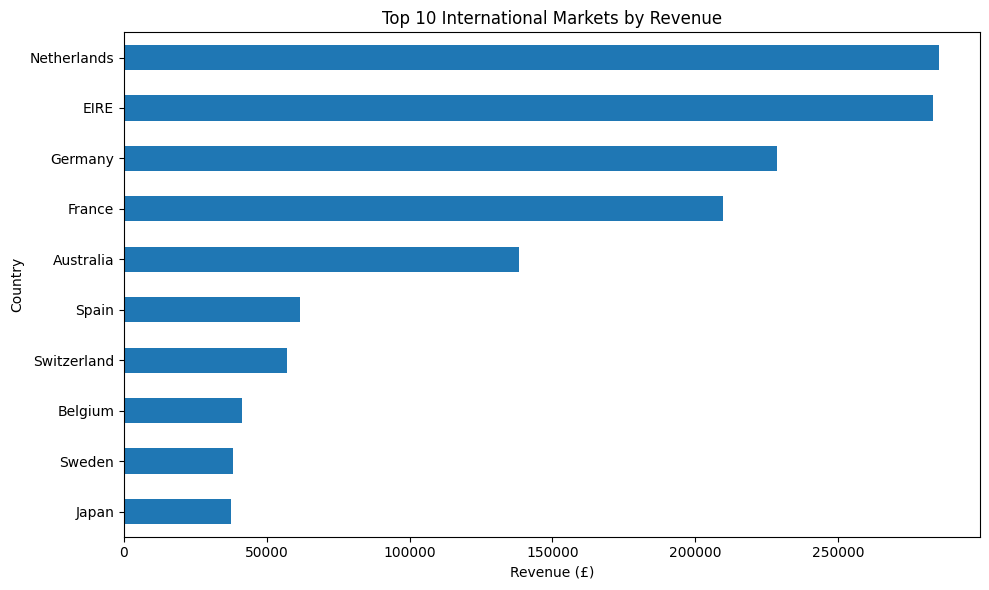

In [21]:
international_revenue = (
    clean_df[clean_df["Country"] != "United Kingdom"]
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

international_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 International Markets by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Product Revenue Analysis

Product-level revenue is analyzed to identify the merchandise generating the highest sales value. Administrative and service entries such as postage are excluded to provide a more meaningful product comparison.

In [22]:
##top products by revenue
top_products = (
    clean_df
    .dropna(subset=["Description"])
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                       206,248.77
REGENCY CAKESTAND 3 TIER             174,156.54
PAPER CRAFT , LITTLE BIRDIE          168,469.60
WHITE HANGING HEART T-LIGHT HOLDER   106,236.72
PARTY BUNTING                         99,445.23
JUMBO BAG RED RETROSPOT               94,159.81
MEDIUM CERAMIC TOP STORAGE JAR        81,700.92
POSTAGE                               78,101.88
Manual                                77,752.82
RABBIT NIGHT LIGHT                    66,870.03
Name: Revenue, dtype: float64

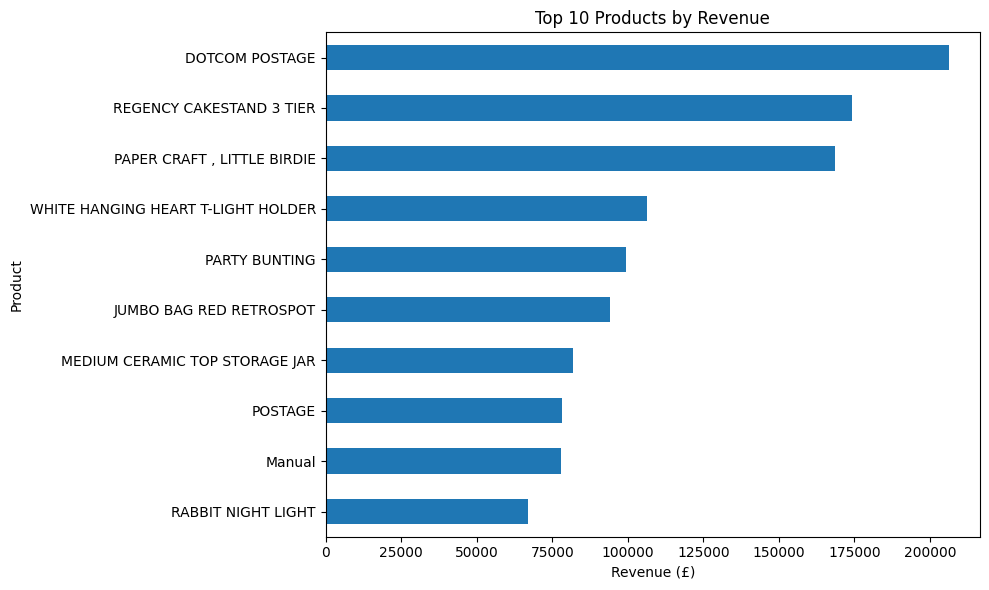

In [23]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [38]:
# Top products by revenue

excluded_items = [
    "DOTCOM POSTAGE",
    "POSTAGE",
    "Manual"
]

top_products = (
    clean_df[
        ~clean_df["Description"].isin(excluded_items)
    ]
    .dropna(subset=["Description"])
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
REGENCY CAKESTAND 3 TIER             174,156.54
PAPER CRAFT , LITTLE BIRDIE          168,469.60
WHITE HANGING HEART T-LIGHT HOLDER   106,236.72
PARTY BUNTING                         99,445.23
JUMBO BAG RED RETROSPOT               94,159.81
MEDIUM CERAMIC TOP STORAGE JAR        81,700.92
RABBIT NIGHT LIGHT                    66,870.03
PAPER CHAIN KIT 50'S CHRISTMAS        64,875.59
ASSORTED COLOUR BIRD ORNAMENT         58,927.62
CHILLI LIGHTS                         54,096.36
Name: Revenue, dtype: float64

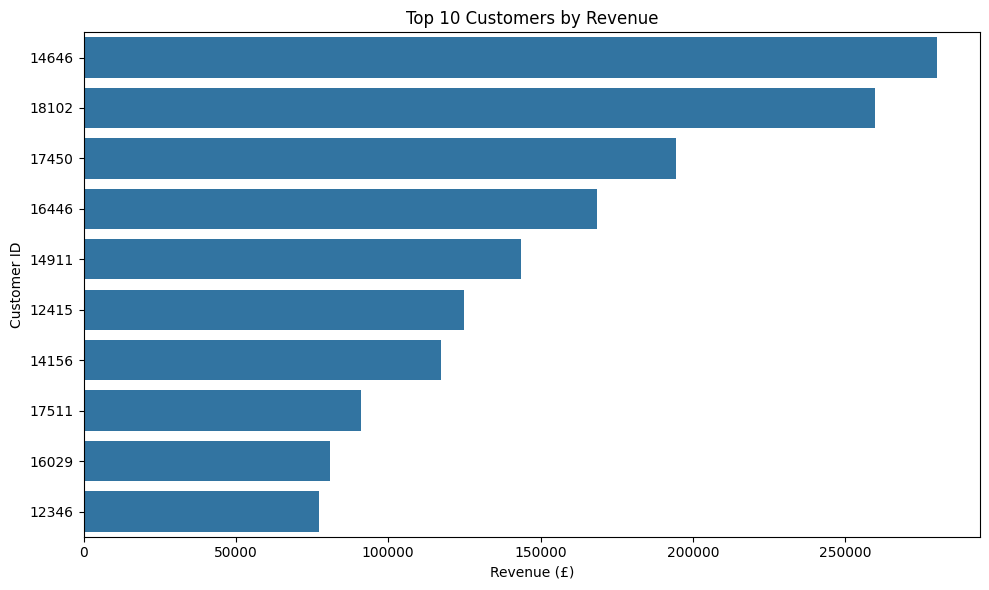

In [39]:
top_customers_df = top_customers.reset_index()

top_customers_df["CustomerID"] = (
    top_customers_df["CustomerID"].astype(str)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers_df,
    x="Revenue",
    y="CustomerID"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

# RFM Customer Segmentation

RFM analysis evaluates customers using three dimensions:

- **Recency:** How recently the customer purchased.
- **Frequency:** How frequently the customer purchased.
- **Monetary:** How much revenue the customer generated.

This allows customers to be grouped based on purchasing behaviour and business value.

In [26]:
analysis_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Latest transaction:", customer_df["InvoiceDate"].max())
print("Analysis date:", analysis_date)

Latest transaction: 2011-12-09 12:50:00
Analysis date: 2011-12-10 12:50:00


In [27]:
rfm = (
    customer_df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


In [28]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",92.54,4.27,"2,048.69"
std,"1,721.81",100.01,7.70,"8,985.23"
min,"12,346.00",1.00,1.00,3.75
25%,"13,813.25",18.00,1.00,306.48
50%,"15,299.50",51.00,2.00,668.57
75%,"16,778.75",142.00,5.00,"1,660.60"
max,"18,287.00",374.00,209.00,"280,206.02"


In [29]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

In [30]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,"77,183.60",1,1,4,6
1,12347,2,7,"4,310.00",4,4,4,12
2,12348,75,4,"1,797.24",2,3,4,9
3,12349,19,1,"1,757.55",3,1,4,8
4,12350,310,1,334.40,1,1,2,4


In [37]:
customer_revenue = (
    customer_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

total_customer_revenue = customer_revenue.sum()

top_10_percent_count = max(
    1,
    int(len(customer_revenue) * 0.10)
)

top_10_percent_revenue = customer_revenue.head(top_10_percent_count).sum()

top_10_revenue_share = (
    top_10_percent_revenue / total_customer_revenue * 100
)

print(f"Top 10% Customers: {top_10_percent_count:,}")
print(f"Revenue Share from Top 10% Customers: {top_10_revenue_share:.2f}%")

Top 10% Customers: 433
Revenue Share from Top 10% Customers: 61.41%


In [32]:
def customer_segment(row):

    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r == 4 and f >= 3 and m >= 3:
        return "Champions"

    elif r >= 3 and f >= 3:
        return "Loyal Customers"

    elif r >= 3 and f <= 2:
        return "Potential Loyalists"

    elif r == 2 and f >= 3 and m >= 3:
        return "Needs Attention"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Hibernating"


rfm["Segment"] = rfm.apply(customer_segment, axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,"77,183.60",1,1,4,6,Hibernating
1,12347,2,7,"4,310.00",4,4,4,12,Champions
2,12348,75,4,"1,797.24",2,3,4,9,Needs Attention
3,12349,19,1,"1,757.55",3,1,4,8,Potential Loyalists
4,12350,310,1,334.40,1,1,2,4,Hibernating


In [33]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
)

segment_counts

Segment
Hibernating            1514
Champions               773
Loyal Customers         741
Potential Loyalists     655
Needs Attention         365
At Risk                 290
Name: count, dtype: int64

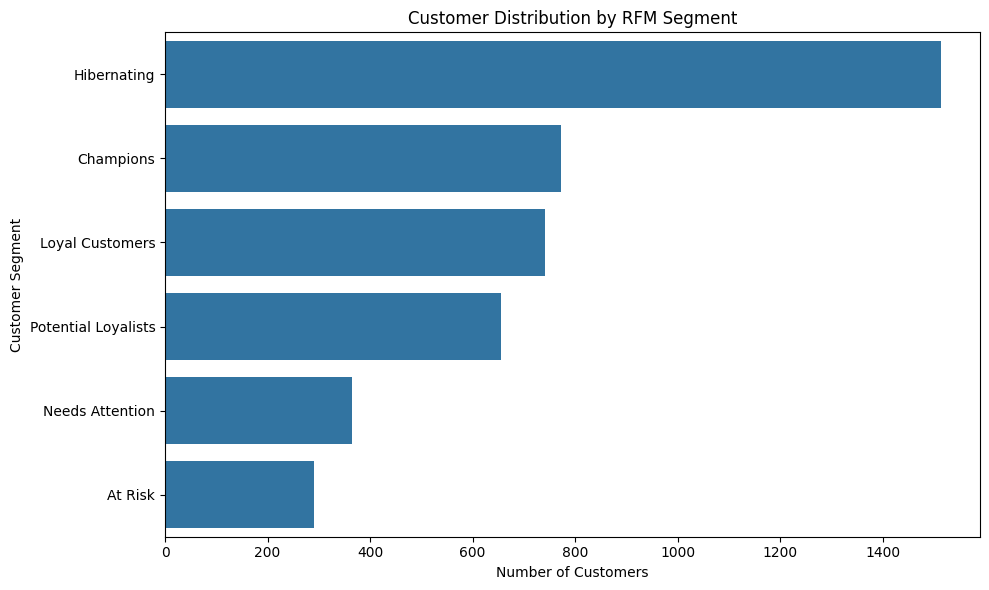

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

In [35]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Champions             4,835,229.21
Loyal Customers       1,734,711.60
Hibernating             770,985.61
Needs Attention         733,571.97
Potential Loyalists     493,878.82
At Risk                 318,831.68
Name: Monetary, dtype: float64

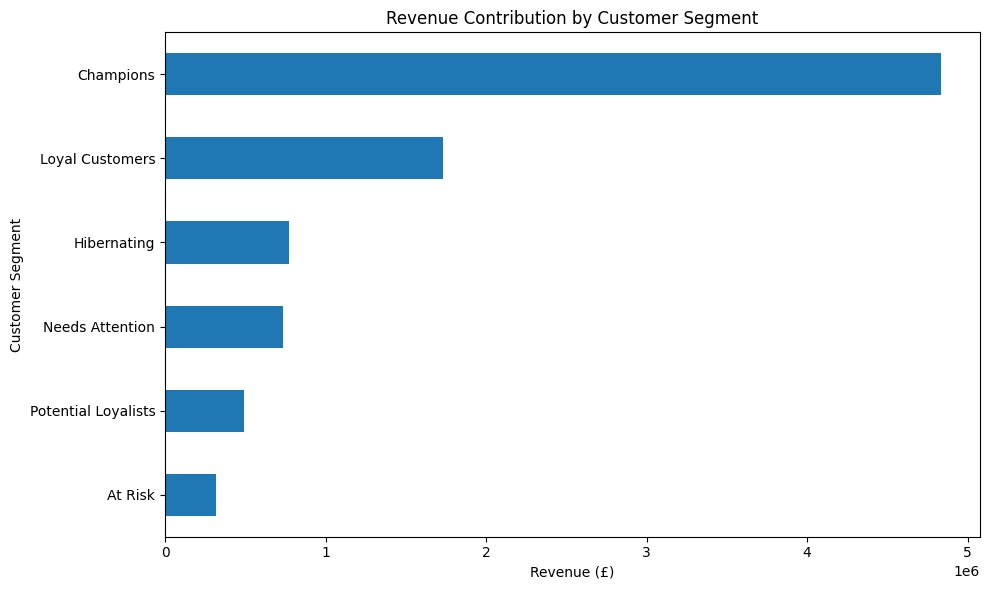

In [36]:
plt.figure(figsize=(10, 6))

segment_revenue.sort_values().plot(kind="barh")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()